In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
months = np.arange(1, 13)

precip = pd.Series([
    38, 35, 32, 38, 50, 65,
    70, 55, 40, 35, 40, 42
])

print("Номер місяця:")
print(months)

print("\nОпади:")
print(precip)


Номер місяця:
[ 1  2  3  4  5  6  7  8  9 10 11 12]

Опади:
0     38
1     35
2     32
3     38
4     50
5     65
6     70
7     55
8     40
9     35
10    40
11    42
dtype: int64


In [13]:
# Завдання 1

print("Місто — номінальна шкала")
print("Номер місяця — порядкова шкала")
print("Кількість опадів — відносна шкала")

print("\nМісто: коректна міра положення — мода.")
print("Номер місяця: за порядковим трактуванням — медіана і мода.")
print("Кількість опадів: середнє, медіана і мода.")


Місто — номінальна шкала
Номер місяця — порядкова шкала
Кількість опадів — відносна шкала

Місто: коректна міра положення — мода.
Номер місяця: за порядковим трактуванням — медіана і мода.
Кількість опадів: середнє, медіана і мода.


In [14]:
# Завдання 2

variation_series = np.sort(precip.values)

print("Варіаційний ряд:")
print(variation_series)


Варіаційний ряд:
[32 35 35 38 38 40 40 42 50 55 65 70]


In [15]:
bins = [31, 41, 50, 60, 70]

intervals = pd.cut(
    precip,
    bins=bins,
    labels=["32–41", "42–50", "51–60", "61–70"]
)

freq = intervals.value_counts().sort_index()
relative = freq / len(precip) * 100
cumulative = freq.cumsum()

frequency_table = pd.DataFrame({
    "абсолютна": freq,
    "відносна_%": relative.round(1),
    "накопичена": cumulative
})

print(frequency_table)


       абсолютна  відносна_%  накопичена
32–41          7        58.3           7
42–50          2        16.7           9
51–60          1         8.3          10
61–70          2        16.7          12


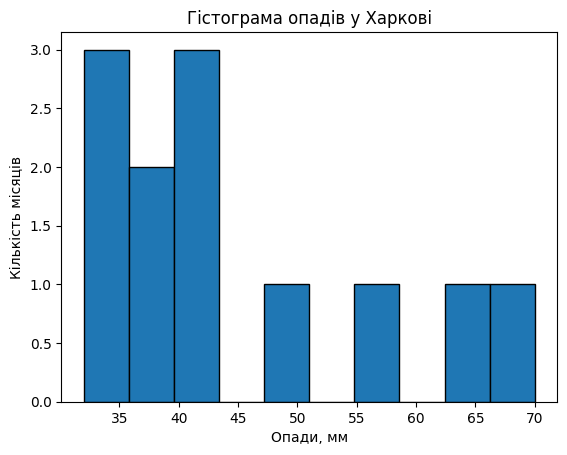

In [16]:
# Завдання 3

plt.hist(precip, edgecolor="black")
plt.xlabel("Опади, мм")
plt.ylabel("Кількість місяців")
plt.title("Гістограма опадів у Харкові")
plt.show()


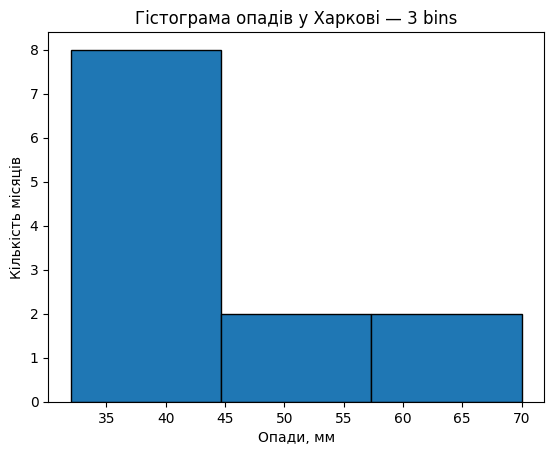

In [17]:
plt.hist(precip, bins=3, edgecolor="black")
plt.xlabel("Опади, мм")
plt.ylabel("Кількість місяців")
plt.title("Гістограма опадів у Харкові — 3 bins")
plt.show()


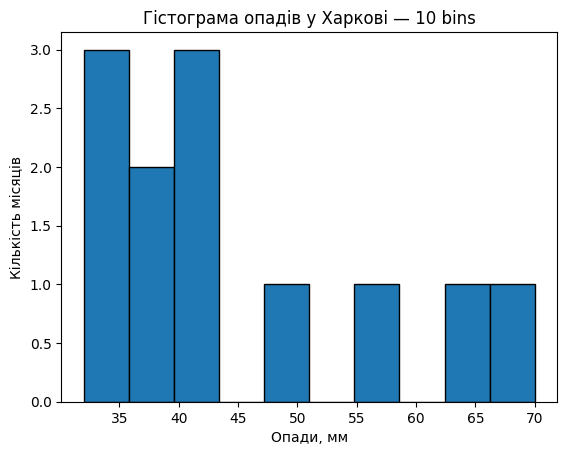

In [18]:
plt.hist(precip, bins=10, edgecolor="black")
plt.xlabel("Опади, мм")
plt.ylabel("Кількість місяців")
plt.title("Гістограма опадів у Харкові — 10 bins")
plt.show()


In [19]:
n = len(precip)

sqrt_rule = np.sqrt(n)
sturges_rule = 1 + np.log2(n)

print("n =", n)
print("Правило √n:", sqrt_rule)
print("Правило Стерджеса:", sturges_rule)


n = 12
Правило √n: 3.4641016151377544
Правило Стерджеса: 4.584962500721156


In [20]:
# Завдання 4

mean_value = precip.mean()
median_value = precip.median()
mode_value = precip.mode()

q1 = precip.quantile(0.25)
q3 = precip.quantile(0.75)

print("Середнє:", mean_value)
print("Медіана:", median_value)
print("Мода:")
print(mode_value)

print("\nQ1:", q1)
print("Q3:", q3)


Середнє: 45.0
Медіана: 40.0
Мода:
0    35
1    38
2    40
dtype: int64

Q1: 37.25
Q3: 51.25


1. Середнє арифметичне некоректне для номінальної змінної «місто»,
тому що назви міст є категоріями, а не числовими значеннями. Навіть
якщо закодувати міста числами, ці числа будуть лише умовними кодами,
тому обчислення їхнього середнього не матиме змістовної інтерпретації.

2. Номер місяця має природний порядок і рівні календарні проміжки,
але не має природного нульового місяця. Тому його можна трактувати
як порядкову шкалу, хоча через особливості календаря можлива також
аргументація на користь інтервальної шкали.

3. Для кількості опадів потрібна гістограма з інтервалами, тому що
майже всі 12 значень є різними. Стовпчикова діаграма за кожним
окремим значенням була б малозмістовною, а гістограма дозволяє
побачити розподіл значень за діапазонами.

4. Накопичена частота на межі третього інтервалу дорівнює 10.
Це означає, що 10 із 12 місяців, або приблизно 83,3%, мають опади
не більші за 60 мм.
